**1. Import Library**

In [1]:
!pip install -q datasets sentence-transformers nltk scikit-learn pandas numpy gradio

In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from datasets import load_dataset
from sentence_transformers import SentenceTransformer, util
from sklearn.model_selection import train_test_split

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

**2. Load Dataset**

In [3]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
dataset = load_dataset("keivalya/MedQuad-MedicalQnADataset")

**3. Cek Dataset**

In [4]:
print(dataset)
print(dataset["train"].column_names)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['qtype', 'Question', 'Answer'],
        num_rows: 16407
    })
})
['qtype', 'Question', 'Answer']
{'qtype': 'susceptibility', 'Question': 'Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?', 'Answer': 'LCMV infections can occur after exposure to fresh urine, droppings, saliva, or nesting materials from infected rodents.  Transmission may also occur when these materials are directly introduced into broken skin, the nose, the eyes, or the mouth, or presumably, via the bite of an infected rodent. Person-to-person transmission has not been reported, with the exception of vertical transmission from infected mother to fetus, and rarely, through organ transplantation.'}


In [5]:
df = dataset["train"].to_pandas()

print("Jumlah data :", len(df))
print("Kolom       :", df.columns.tolist())

display(df.head())

Jumlah data : 16407
Kolom       : ['qtype', 'Question', 'Answer']


,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."


In [6]:
df.to_csv(
    "medquad.csv",
    index=False
)

print("Data berhasil disimpan!")
print("Jumlah data:", len(df))

Data berhasil disimpan!
Jumlah data: 16407


In [7]:
print("Missing value:")
print(df.isnull().sum())

Missing value:
qtype       0
Question    0
Answer      0
dtype: int64


In [8]:
print("Duplicate question:")
print(df.duplicated(subset=["Question"]).sum())

print("\nDuplicate question-answer pair:")
print(df.duplicated(subset=["Question", "Answer"]).sum())

Duplicate question:
1428

Duplicate question-answer pair:
48


**4. Data Cleaning**

In [9]:
# Ambil pertanyaan yang muncul lebih dari sekali
duplicate_questions = df[
    df.duplicated(subset=["Question"], keep=False)
].sort_values("Question")

display(
    duplicate_questions[
        ["qtype", "Question", "Answer"]
    ].head(20)
)

,qtype,Question,Answer
1490,exams and tests,How to diagnose Adrenal Insufficiency and Addi...,"In its early stages, adrenal insufficiency can..."
1491,exams and tests,How to diagnose Adrenal Insufficiency and Addi...,"After Addisons disease is diagnosed, health ca..."
3966,exams and tests,How to diagnose Alzheimer's Caregiving ?,When you learn that someone has Alzheimers dis...
3960,exams and tests,How to diagnose Alzheimer's Caregiving ?,Now that your family member or friend has rece...
3742,exams and tests,How to diagnose Alzheimer's Disease ?,The only definitive way to diagnose Alzheimer'...
3743,exams and tests,How to diagnose Alzheimer's Disease ?,"An early, accurate diagnosis of Alzheimer's di..."
3744,exams and tests,How to diagnose Alzheimer's Disease ?,The time from diagnosis of Alzheimers disease ...
1561,exams and tests,How to diagnose Amyloidosis and Kidney Disease ?,A health care provider diagnoses primary amylo...
1562,exams and tests,How to diagnose Amyloidosis and Kidney Disease ?,A health care provider diagnoses dialysis-rela...
3002,exams and tests,How to diagnose Breast Cancer ?,Tests that examine the breasts are used to det...


In [10]:
sample_question = duplicate_questions["Question"].iloc[0]

print("QUESTION:")
print(sample_question)

print("\nANSWERS:")
answers = df[df["Question"] == sample_question]["Answer"]

for i, answer in enumerate(answers, 1):
    print(f"\n--- Answer {i} ---")
    print(answer)

QUESTION:
How to diagnose Adrenal Insufficiency and Addison's Disease ?

ANSWERS:

--- Answer 1 ---
In its early stages, adrenal insufficiency can be difficult to diagnose. A health care provider may suspect it after reviewing a persons medical history and symptoms.
                
A diagnosis of adrenal insufficiency is confirmed through hormonal blood and urine tests. A health care provider uses these tests first to determine whether cortisol levels are too low and then to establish the cause. Imaging studies of the adrenal and pituitary glands can be useful in helping to establish the cause.
                
A lab technician performs the following tests in a health care providers office, a commercial facility, or a hospital.
                
Hormonal Blood and Urine Tests
                
- ACTH stimulation test. The ACTH stimulation test is the most commonly used test for diagnosing adrenal insufficiency. In this test, the patient is given an intravenous (IV) injection of syntheti

In [11]:
print("Jumlah data sebelum penggabungan :", len(df))
print("Jumlah pertanyaan unik           :", df["Question"].nunique())

Jumlah data sebelum penggabungan : 16407
Jumlah pertanyaan unik           : 14979


In [12]:
# Gabungkan jawaban dari pertanyaan yang sama
df_clean = (
    df.groupby(["qtype", "Question"], as_index=False)
      .agg({
          "Answer": lambda x: "\n\n".join(dict.fromkeys(x))
      })
)

print("Jumlah data sebelum :", len(df))
print("Jumlah data sesudah :", len(df_clean))

Jumlah data sebelum : 16407
Jumlah data sesudah : 14979


**5. Data Analysis**

In [13]:
df_clean["question_words"] = (
    df_clean["Question"]
    .str.split()
    .str.len()
)

df_clean["answer_words"] = (
    df_clean["Answer"]
    .str.split()
    .str.len()
)

In [14]:
df_clean[
    ["question_words", "answer_words"]
].describe()

,question_words,answer_words
count,14979.000000,14979.000000
mean,8.286201,218.826157
std,2.352074,294.915218
min,3.000000,1.000000
25%,6.000000,72.000000
50%,8.000000,144.000000
75%,10.000000,265.000000
max,27.000000,6738.000000


In [15]:
# Jawaban paling pendek
display(
    df_clean.nsmallest(5, "answer_words")[
        ["qtype", "Question", "Answer", "answer_words"]
    ]
)

,qtype,Question,Answer,answer_words
9211,prevention,How to prevent Acanthamoeba - Granulomatous Am...,Topics,1
69,causes,What causes Bell's palsy ?,What causes Bell's palsy?,4
5962,information,What is (are) Parasites - African Trypanosomia...,Frequently Asked Queestions (FAQs),4
5980,information,What is (are) Parasites - Paragonimiasis (also...,Frequently Asked Queestions (FAQs),4
8053,inheritance,Is Septo-optic dysplasia inherited ?,Is septo-optic dysplasia inherited?,4


In [16]:
# Jawaban paling panjang
display(
   df_clean.nlargest(5, "answer_words")[
        ["qtype", "Question", "Answer", "answer_words"]
    ]
)

,qtype,Question,Answer,answer_words
12974,treatment,What are the treatments for Breast Cancer ?,Key Points\n - Treatment op...,6738
9869,susceptibility,Who is at risk for Breast Cancer? ?,Sometimes breast cancer occurs in women who ar...,6684
13960,treatment,What are the treatments for Prostate Cancer ?,Key Points\n - There are di...,4725
13066,treatment,What are the treatments for Childhood Soft Tis...,Key Points\n - There are di...,3708
4481,information,What is (are) Childhood Vascular Tumors ?,Key Points\n - Childhood va...,3692


**6. Model Sentence-BERT**

In [17]:
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Model berhasil dimuat.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model berhasil dimuat.


In [18]:
knowledge_base = df_clean[
    ["qtype", "Question", "Answer"]
].copy()

print("Jumlah knowledge base :", len(knowledge_base))

display(knowledge_base.head())

Jumlah knowledge base : 14979


,qtype,Question,Answer
0,causes,What causes 15q11.2 microdeletion ?,What causes a 15q11.2 microdeletion? A 15q11.2...
1,causes,What causes 17q23.1q23.2 microdeletion syndrome ?,What causes 17q23.2q23.2 microdeletion syndrom...
2,causes,What causes 21-hydroxylase deficiency ?,"What causes salt-wasting, simple virilizing, a..."
3,causes,What causes 22q11.2 deletion syndrome ?,What causes 22q11.2 deletion syndrome? 22q11.2...
4,causes,What causes 2q37 deletion syndrome ?,What causes 2q37 deletion syndrome? 2q37 delet...


In [19]:
questions = knowledge_base["Question"].tolist()

question_embeddings = model.encode(
    questions,
    convert_to_tensor=True,
    show_progress_bar=True
)

print("Jumlah pertanyaan :", len(questions))
print("Ukuran embedding  :", question_embeddings.shape)

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

Jumlah pertanyaan : 14979
Ukuran embedding  : torch.Size([14979, 384])


**7. Similarity & Retrieval**

In [20]:
def search_question(user_question):
    # Encode pertanyaan pengguna
    query_embedding = model.encode(
        user_question,
        convert_to_tensor=True
    )

    # Hitung cosine similarity
    similarities = util.cos_sim(
        query_embedding,
        question_embeddings
    )[0]

    # Ambil hasil dengan similarity tertinggi
    best_idx = similarities.argmax().item()
    best_score = similarities[best_idx].item()

    result = knowledge_base.iloc[best_idx]

    return {
        "qtype": result["qtype"],
        "question": result["Question"],
        "answer": result["Answer"],
        "similarity": best_score
    }

In [21]:
result = search_question(
    "What are the symptoms of diabetes?"
)

print("MATCHED QUESTION:")
print(result["question"])

print("\nCATEGORY:")
print(result["qtype"])

print("\nSIMILARITY:")
print(round(result["similarity"], 4))

print("\nANSWER:")
print(result["answer"])

MATCHED QUESTION:
What are the symptoms of Diabetes ?

CATEGORY:
symptoms

SIMILARITY:
1.0

ANSWER:
Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the Centers for Disease Control and Prevention (CDC). Common Signs Some common symptoms of diabetes are: - being very thirsty  - frequent urination  - feeling very hungry or tired  - losing weight without trying  - having sores that heal slowly  - having dry, itchy skin  - loss of feeling or tingling in the feet  - having blurry eyesight. being very thirsty frequent urination feeling very hungry or tired losing weight without trying having sores that heal slowly having dry, itchy skin loss of feeling or tingling in the feet having blurry eyesight. Signs of type 1 diabetes usually develop over a sho

In [22]:
result = search_question(
    "What signs might indicate that someone has diabetes?"
)

print("MATCHED QUESTION:")
print(result["question"])

print("\nCATEGORY:")
print(result["qtype"])

print("\nSIMILARITY:")
print(round(result["similarity"], 4))

print("\nANSWER:")
print(result["answer"])

MATCHED QUESTION:
What are the symptoms of Diabetes ?

CATEGORY:
symptoms

SIMILARITY:
0.8775

ANSWER:
Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the Centers for Disease Control and Prevention (CDC). Common Signs Some common symptoms of diabetes are: - being very thirsty  - frequent urination  - feeling very hungry or tired  - losing weight without trying  - having sores that heal slowly  - having dry, itchy skin  - loss of feeling or tingling in the feet  - having blurry eyesight. being very thirsty frequent urination feeling very hungry or tired losing weight without trying having sores that heal slowly having dry, itchy skin loss of feeling or tingling in the feet having blurry eyesight. Signs of type 1 diabetes usually develop over a 

In [23]:
def search_top_k(user_question, k=3):
    query_embedding = model.encode(
        user_question,
        convert_to_tensor=True
    )

    similarities = util.cos_sim(
        query_embedding,
        question_embeddings
    )[0]

    top_results = similarities.topk(k)

    results = []

    for score, idx in zip(
        top_results.values,
        top_results.indices
    ):
        idx = idx.item()

        results.append({
            "index": idx,
            "qtype": knowledge_base.iloc[idx]["qtype"],
            "question": knowledge_base.iloc[idx]["Question"],
            "answer": knowledge_base.iloc[idx]["Answer"],
            "similarity": score.item()
        })

    return results

In [24]:
results = search_top_k(
    "What signs might indicate that someone has diabetes?",
    k=3
)

for i, result in enumerate(results, 1):
    print(f"TOP {i}")
    print("Question   :", result["question"])
    print("Category   :", result["qtype"])
    print("Similarity :", round(result["similarity"], 4))
    print()

TOP 1
Question   : What are the symptoms of Diabetes ?
Category   : symptoms
Similarity : 0.8775

TOP 2
Question   : What are the symptoms of Diabetes mellitus type 1 ?
Category   : symptoms
Similarity : 0.8038

TOP 3
Question   : What are the symptoms of Maturity-onset diabetes of the young, type 5 ?
Category   : symptoms
Similarity : 0.773



**8. Evaluasi**

In [25]:
eval_sample = (
    df_clean
    .groupby("qtype", group_keys=False)
    .apply(
        lambda x: x.sample(
            min(2, len(x)),
            random_state=42
        )
    )
    .reset_index(drop=True)
)

# Ambil 30 pertanyaan untuk evaluasi
eval_sample = eval_sample[
    ["qtype", "Question"]
].head(30)

print("Jumlah data evaluasi:", len(eval_sample))

Jumlah data evaluasi: 30


/tmp/ipykernel_3857/4150288150.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [26]:
pd.set_option("display.max_colwidth", None)

display(
    eval_sample[["qtype", "Question"]]
)

for i, row in eval_sample.iterrows():
    print(f'{i}. {row["Question"]}')

,qtype,Question
0,causes,What causes Von Willebrand Disease ?
1,causes,What causes Heart Palpitations ?
2,complications,What are the complications of Urine Blockage in Newborns ?
3,complications,What are the complications of Neurological Complications of AIDS ?
4,considerations,What to do for Hypothyroidism ?
5,considerations,What to do for Mineral and Bone Disorder in Chronic Kidney Disease ?
6,exams and tests,How to diagnose Bronchitis ?
7,exams and tests,How to diagnose Gardner-Diamond syndrome ?
8,frequency,How many people are affected by Mabry syndrome ?
9,frequency,How many people are affected by Christianson syndrome ?


0. What causes Von Willebrand Disease ?
1. What causes Heart Palpitations ?
2. What are the complications of Urine Blockage in Newborns ?
3. What are the complications of Neurological Complications of AIDS ?
4. What to do for Hypothyroidism ?
5. What to do for Mineral and Bone Disorder in Chronic Kidney Disease ?
6. How to diagnose Bronchitis ?
7. How to diagnose Gardner-Diamond syndrome ?
8. How many people are affected by Mabry syndrome ?
9. How many people are affected by Christianson syndrome ?
10. What are the genetic changes related to hyperparathyroidism-jaw tumor syndrome ?
11. What are the genetic changes related to Bannayan-Riley-Ruvalcaba syndrome ?
12. What is (are) autoimmune polyglandular syndrome, type 1 ?
13. What is (are) recombinant 8 syndrome ?
14. Is Hereditary diffuse leukoencephalopathy with spheroids inherited ?
15. Is arginase deficiency inherited ?
16. What is the outlook for Myopathy ?
17. What is the outlook for Bile Duct Cancer (Cholangiocarcinoma) ?
18. How

In [27]:
# parafrase pertanyaan untuk melakukan evaluasi (test)
paraphrases = [
    "What causes Von Willebrand disease to occur?",
    "What can cause heart palpitations?",
    "What complications can occur from urine blockage in newborns?",
    "What complications can result from neurological complications of AIDS?",
    "How should hypothyroidism be managed?",
    "How should mineral and bone disorder in chronic kidney disease be managed?",
    "How is bronchitis diagnosed?",
    "How can Gardner-Diamond syndrome be diagnosed?",
    "How common is Mabry syndrome?",
    "How common is Christianson syndrome?",
    "Which genetic changes are associated with hyperparathyroidism-jaw tumor syndrome?",
    "Which genetic changes are associated with Bannayan-Riley-Ruvalcaba syndrome?",
    "What is autoimmune polyglandular syndrome type 1?",
    "Can you explain recombinant 8 syndrome?",
    "How is hereditary diffuse leukoencephalopathy with spheroids inherited?",
    "How is arginase deficiency inherited?",
    "What is the prognosis for myopathy?",
    "What is the prognosis for bile duct cancer or cholangiocarcinoma?",
    "What can be done to prevent balance problems?",
    "How can diabetic heart disease be prevented?",
    "What research or clinical trials are being conducted for striatonigral degeneration?",
    "What research or clinical trials are being conducted for attention deficit-hyperactivity disorder?",
    "What are the different stages of adult Hodgkin lymphoma?",
    "What are the different stages of hypopharyngeal cancer?",
    "Where can older adults with alcohol use problems find support?",
    "Who has a higher risk of developing arrhythmia?",
    "Who is at risk of developing adult acute myeloid leukemia?",
    "What signs and symptoms occur in Teebi Kaurah syndrome?",
    "What signs and symptoms occur in hereditary endotheliopathy, retinopathy, nephropathy, and stroke?",
    "How is Mainzer-Saldino syndrome treated?"
]

eval_data = eval_sample.copy()
eval_data["query"] = paraphrases

display(eval_data[["Question", "query"]])

,Question,query
0,What causes Von Willebrand Disease ?,What causes Von Willebrand disease to occur?
1,What causes Heart Palpitations ?,What can cause heart palpitations?
2,What are the complications of Urine Blockage in Newborns ?,What complications can occur from urine blockage in newborns?
3,What are the complications of Neurological Complications of AIDS ?,What complications can result from neurological complications of AIDS?
4,What to do for Hypothyroidism ?,How should hypothyroidism be managed?
5,What to do for Mineral and Bone Disorder in Chronic Kidney Disease ?,How should mineral and bone disorder in chronic kidney disease be managed?
6,How to diagnose Bronchitis ?,How is bronchitis diagnosed?
7,How to diagnose Gardner-Diamond syndrome ?,How can Gardner-Diamond syndrome be diagnosed?
8,How many people are affected by Mabry syndrome ?,How common is Mabry syndrome?
9,How many people are affected by Christianson syndrome ?,How common is Christianson syndrome?


In [28]:
evaluation_results = []

for _, row in eval_data.iterrows():
    results = search_top_k(row["query"], k=3)

    retrieved_questions = [
        result["question"]
        for result in results
    ]

    target = row["Question"]

    top1_correct = retrieved_questions[0] == target
    top3_correct = target in retrieved_questions

    if target in retrieved_questions:
        rank = retrieved_questions.index(target) + 1
    else:
        rank = None

    evaluation_results.append({
        "query": row["query"],
        "target": target,
        "retrieved_top1": retrieved_questions[0],
        "similarity": results[0]["similarity"],
        "top1_correct": top1_correct,
        "top3_correct": top3_correct,
        "rank": rank
    })

evaluation_df = pd.DataFrame(evaluation_results)

display(evaluation_df)

,query,target,retrieved_top1,similarity,top1_correct,top3_correct,rank
0,What causes Von Willebrand disease to occur?,What causes Von Willebrand Disease ?,What causes Von Willebrand disease ?,0.989961,False,True,2
1,What can cause heart palpitations?,What causes Heart Palpitations ?,What causes Heart Palpitations ?,0.967992,True,True,1
2,What complications can occur from urine blockage in newborns?,What are the complications of Urine Blockage in Newborns ?,What are the complications of Urine Blockage in Newborns ?,0.987882,True,True,1
3,What complications can result from neurological complications of AIDS?,What are the complications of Neurological Complications of AIDS ?,What are the complications of Neurological Complications of AIDS ?,0.981094,True,True,1
4,How should hypothyroidism be managed?,What to do for Hypothyroidism ?,What to do for Hypothyroidism ?,0.894106,True,True,1
5,How should mineral and bone disorder in chronic kidney disease be managed?,What to do for Mineral and Bone Disorder in Chronic Kidney Disease ?,What to do for Mineral and Bone Disorder in Chronic Kidney Disease ?,0.927346,True,True,1
6,How is bronchitis diagnosed?,How to diagnose Bronchitis ?,How to diagnose Bronchitis ?,0.883264,True,True,1
7,How can Gardner-Diamond syndrome be diagnosed?,How to diagnose Gardner-Diamond syndrome ?,How to diagnose Gardner-Diamond syndrome ?,0.951432,True,True,1
8,How common is Mabry syndrome?,How many people are affected by Mabry syndrome ?,How many people are affected by Mabry syndrome ?,0.863728,True,True,1
9,How common is Christianson syndrome?,How many people are affected by Christianson syndrome ?,How many people are affected by Christianson syndrome ?,0.873710,True,True,1


In [29]:
evaluation_df["similarity"].describe()

,similarity
count,30.000000
mean,0.946510
std,0.048663
min,0.801348
25%,0.918430
50%,0.966665
75%,0.984785
max,0.989961


In [30]:
accuracy_at_1 = evaluation_df["top1_correct"].mean()
accuracy_at_3 = evaluation_df["top3_correct"].mean()

evaluation_df["reciprocal_rank"] = (
    evaluation_df["rank"]
    .apply(lambda x: 1 / x if pd.notna(x) else 0)
)

mrr = evaluation_df["reciprocal_rank"].mean()

average_similarity = evaluation_df["similarity"].mean()

print(f"Accuracy@1       : {accuracy_at_1:.2%}")
print(f"Accuracy@3       : {accuracy_at_3:.2%}")
print(f"MRR              : {mrr:.4f}")
print(f"Average Similarity: {average_similarity:.4f}")

Accuracy@1       : 93.33%
Accuracy@3       : 100.00%
MRR              : 0.9667
Average Similarity: 0.9465


In [31]:
wrong_results = evaluation_df[
    evaluation_df["top1_correct"] == False
]

display(
    wrong_results[
        [
            "query",
            "target",
            "retrieved_top1",
            "similarity",
            "rank"
        ]
    ]
)

,query,target,retrieved_top1,similarity,rank
0,What causes Von Willebrand disease to occur?,What causes Von Willebrand Disease ?,What causes Von Willebrand disease ?,0.989961,2
12,What is autoimmune polyglandular syndrome type 1?,"What is (are) autoimmune polyglandular syndrome, type 1 ?",What is (are) Autoimmune polyglandular syndrome type 1 ?,0.988124,2


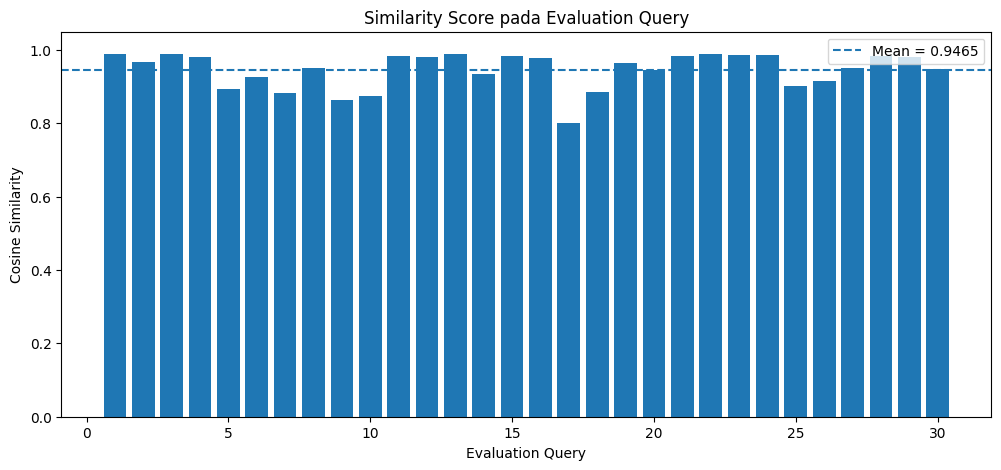

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.bar(
    range(1, len(evaluation_df) + 1),
    evaluation_df["similarity"]
)

plt.axhline(
    y=evaluation_df["similarity"].mean(),
    linestyle="--",
    label=f'Mean = {evaluation_df["similarity"].mean():.4f}'
)

plt.xlabel("Evaluation Query")
plt.ylabel("Cosine Similarity")
plt.title("Similarity Score pada Evaluation Query")
plt.ylim(0, 1.05)
plt.legend()

plt.show()

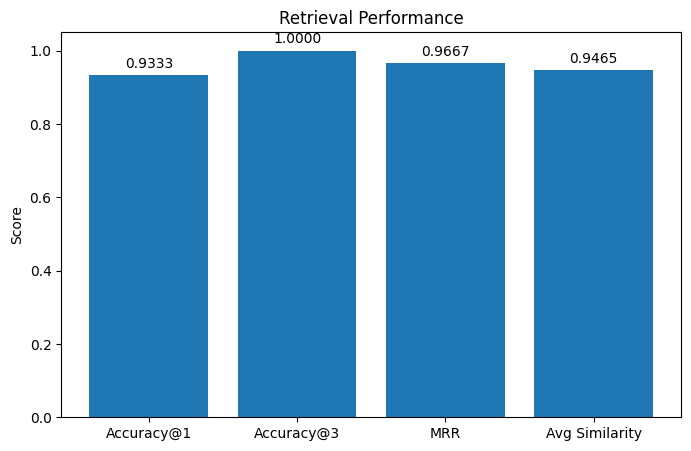

In [33]:
metrics = {
    "Accuracy@1": accuracy_at_1,
    "Accuracy@3": accuracy_at_3,
    "MRR": mrr,
    "Avg Similarity": average_similarity
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Retrieval Performance")

for bar, value in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.show()

**9. Conf Threshold**

In [34]:
CONFIDENCE_THRESHOLD = 0.50

In [35]:
def medical_chatbot(user_question):
    results = search_top_k(
        user_question,
        k=3
    )

    best_result = results[0]

    # Jika similarity terlalu rendah
    if best_result["similarity"] < CONFIDENCE_THRESHOLD:
        return {
            "status": "low_confidence",
            "answer": (
                "Sorry, I could not find sufficiently relevant "
                "medical information for your question."
            ),
            "matched_question": best_result["question"],
            "similarity": best_result["similarity"],
            "related_questions": []
        }

    # Jika similarity memenuhi threshold
    return {
        "status": "success",
        "answer": best_result["answer"],
        "matched_question": best_result["question"],
        "similarity": best_result["similarity"],
        "related_questions": [
            result["question"]
            for result in results[1:]
        ]
    }

In [36]:
result = medical_chatbot(
    "What signs might indicate nasopharyngeal cancer?"
)

print("Status             :", result["status"])
print("Matched Question   :", result["matched_question"])
print("Similarity         :", round(result["similarity"], 4))
print("\nAnswer:")
print(result["answer"])

print("\nRelated Questions:")
for question in result["related_questions"]:
    print("-", question)

Status             : success
Matched Question   : What are the symptoms of Nasopharyngeal Cancer ?
Similarity         : 0.9284

Answer:
Signs of nasopharyngeal cancer include trouble breathing, speaking, or hearing. These and other signs and symptoms may be caused by nasopharyngeal cancer or by other conditions. Check with your doctor if you have any of the following:         - A lump in the nose or neck.    - A sore throat.    - Trouble breathing or speaking.    - Nosebleeds.    - Trouble hearing.    - Pain or ringing in the ear.    - Headaches.

Related Questions:
- What are the symptoms of Nasopharyngeal carcinoma ?
- How to diagnose Nasopharyngeal Cancer ?


In [37]:
# Tes pertanyaan tdk relevan
result = medical_chatbot(
    "How do I cook fried rice?"
)

print("Status           :", result["status"])
print("Matched Question :", result["matched_question"])
print("Similarity       :", round(result["similarity"], 4))
print("\nAnswer:")
print(result["answer"])

Status           : low_confidence
Matched Question : What are the treatments for Fryns syndrome ?
Similarity       : 0.3376

Answer:
Sorry, I could not find sufficiently relevant medical information for your question.


In [38]:
# Tes bbrp query
test_queries = [
    "What are the symptoms of diabetes?",
    "How can sickle cell disease be prevented?",
    "Who is at risk for metabolic syndrome?",
    "How is schizophrenia diagnosed?",
    "How do I cook fried rice?",
    "What is the best gaming laptop?",
    "Who won the football match yesterday?",
    "How do I learn Python?"
]

for query in test_queries:
    result = medical_chatbot(query)

    print("=" * 70)
    print("Query      :", query)
    print("Similarity :", round(result["similarity"], 4))
    print("Status     :", result["status"])
    print("Matched    :", result["matched_question"])

Query      : What are the symptoms of diabetes?
Similarity : 1.0
Status     : success
Matched    : What are the symptoms of Diabetes ?
Query      : How can sickle cell disease be prevented?
Similarity : 0.947
Status     : success
Matched    : How to prevent Sickle Cell Disease ?
Query      : Who is at risk for metabolic syndrome?
Similarity : 0.9745
Status     : success
Matched    : Who is at risk for Metabolic Syndrome? ?
Query      : How is schizophrenia diagnosed?
Similarity : 0.7819
Status     : success
Matched    : What is (are) Schizophrenia ?
Query      : How do I cook fried rice?
Similarity : 0.3376
Status     : low_confidence
Matched    : What are the treatments for Fryns syndrome ?
Query      : What is the best gaming laptop?
Similarity : 0.2082
Status     : low_confidence
Matched    : What are the treatments for multiple sclerosis ?
Query      : Who won the football match yesterday?
Similarity : 0.1991
Status     : low_confidence
Matched    : What is (are) Athlete's Foot ?
Q

**10. ChatBot**

In [42]:
def medical_chatbot(user_question):
    if not user_question.strip():
        return {
            "status": "empty",
            "answer": "Please enter a medical question.",
            "matched_question": None,
            "qtype": None,
            "similarity": 0.0,
            "related_questions": []
        }

    results = search_top_k(
        user_question,
        k=3
    )

    best_result = results[0]

    if best_result["similarity"] < CONFIDENCE_THRESHOLD:
        return {
            "status": "low_confidence",
            "answer": (
                "Sorry, I could not find sufficiently relevant "
                "medical information for your question."
            ),
            "matched_question": best_result["question"],
            "qtype": best_result["qtype"],
            "similarity": best_result["similarity"],
            "related_questions": []
        }

    return {
        "status": "success",
        "answer": best_result["answer"],
        "matched_question": best_result["question"],
        "qtype": best_result["qtype"],
        "similarity": best_result["similarity"],
        "related_questions": [
            result["question"]
            for result in results[1:]
        ]
    }

In [40]:
while True:
    user_input = input("\nYou: ")

    if user_input.lower() in ["exit", "quit"]:
        print("Chatbot: Goodbye!")
        break

    result = medical_chatbot(user_input)

    print("\nChatbot:", result["answer"])

    if result["status"] == "success":
        print(
            f"\nMatched Question: "
            f"{result['matched_question']}"
        )

        print(
            f"Category: {result['qtype']}"
        )

        print(
            f"Similarity: "
            f"{result['similarity']:.4f}"
        )

        if result["related_questions"]:
            print("\nRelated Questions:")

            for question in result["related_questions"]:
                print("-", question)


You: what is diabetes

Chatbot: Too Much Glucose in the Blood Diabetes means your blood glucose (often called blood sugar) is too high. Your blood always has some glucose in it because your body needs glucose for energy to keep you going. But too much glucose in the blood isn't good for your health. Glucose comes from the food you eat and is also made in your liver and muscles. Your blood carries the glucose to all of the cells in your body. Insulin is a chemical (a hormone) made by the pancreas. The pancreas releases insulin into the blood. Insulin helps the glucose from food get into your cells. If your body does not make enough insulin or if the insulin doesn't work the way it should, glucose can't get into your cells. It stays in your blood instead. Your blood glucose level then gets too high, causing pre-diabetes or diabetes. Types of Diabetes There are three main kinds of diabetes: type 1, type 2, and gestational diabetes. The result of type 1 and type 2 diabetes is the same: gl

11. Save Model

In [41]:
np.save(
    "question_embeddings.npy",
    question_embeddings.cpu().numpy()
)

knowledge_base.to_csv(
    "knowledge_base.csv",
    index=False
)